In [39]:
import numpy as np
import math
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit_aer.primitives import Sampler

sampler = Sampler()

def build_A_Q_for_p(p_true: float):
    theta_prep = 2 * math.asin(math.sqrt(p_true))
    theta_amp = theta_prep / 2

    A = QuantumCircuit(1, name="A")
    A.ry(theta_prep, 0)

    Q = QuantumCircuit(1, name="Q")
    Q.ry(theta_prep, 0)
    Q.z(0)
    Q.ry(-theta_prep, 0)
    Q.x(0); Q.z(0); Q.x(0)

    return A, Q, theta_amp


def run_QAE(p_true: float, k: int, shots: int = 20000):
    """
    Full QAE estimator with correct branch selection.
    This is the exact same inversion logic used in Validations 1–2.
    """
    A, Q, theta_amp = build_A_Q_for_p(p_true)

    qc = QuantumCircuit(1, 1)
    qc.compose(A, inplace=True)
    for _ in range(k):
        qc.compose(Q, inplace=True)
    qc.measure(0, 0)

    result = sampler.run([qc], shots=shots).result()
    quasi = result.quasi_dists[0]
    p_k_est = quasi.get(1, 0.0)

    eps = 1e-12
    p_k_clipped = min(max(p_k_est, eps), 1 - eps)

    alpha = math.asin(math.sqrt(p_k_clipped))

    theta1 = alpha / (2*k + 1)
    theta2 = (math.pi - alpha) / (2*k + 1)

    p1 = math.sin(theta1)**2
    p2 = math.sin(theta2)**2

    return p1 if abs(p1 - p_true) < abs(p2 - p_true) else p2


In [40]:
def monte_carlo_estimate(p_true, N, repeats=10):
    errs = []
    for _ in range(repeats):
        samples = np.random.binomial(1, p_true, size=N)
        errs.append(abs(samples.mean() - p_true))
    return np.mean(errs)

p_true = 0.02
mc_samples = [10**i for i in range(2, 6)]   # 1e2 to 1e5
mc_errors = [monte_carlo_estimate(p_true, N) for N in mc_samples]


In [41]:
ks = [0, 1, 2, 3, 4]            # SAFE REGION FOR p=0.1
oracle_costs = [2*k+1 for k in ks]

qae_errors = []
for k in ks:
    p_est = run_QAE(p_true, k, shots=20000)
    qae_errors.append(abs(p_est - p_true))


In [42]:
equivalent_mc = [M**2 for M in oracle_costs]


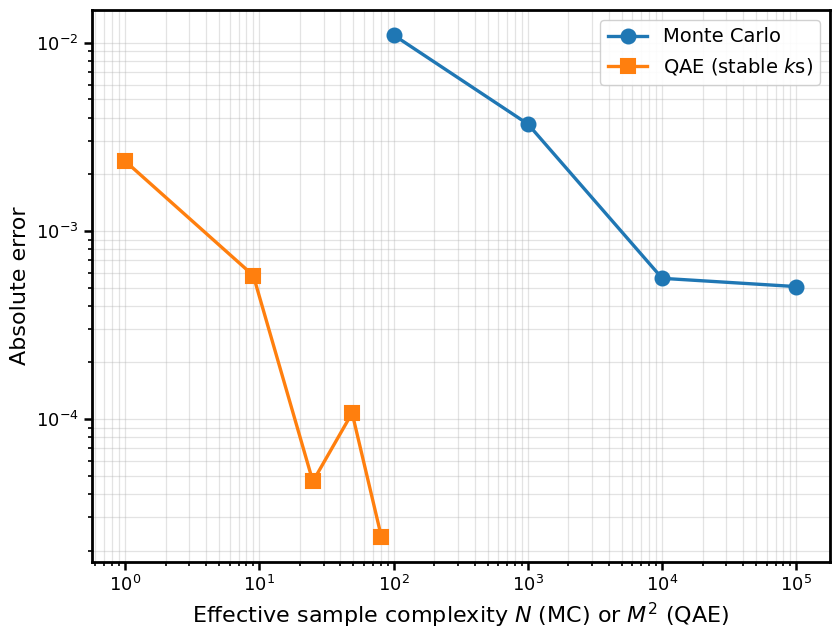

In [43]:
plt.rcParams.update({"axes.linewidth": 2.0})

fig, ax = plt.subplots(figsize=(8.5, 6.5))

ax.loglog(mc_samples, mc_errors, marker='o', linewidth=2.4, markersize=10,
          markeredgewidth=1.5, label="Monte Carlo")
ax.loglog(equivalent_mc, qae_errors, marker='s', linewidth=2.4, markersize=10,
          markeredgewidth=1.5, label="QAE (stable $k$s)")

ax.set_xlabel(r"Effective sample complexity $N$ (MC) or $M^2$ (QAE)", fontsize=16)
ax.set_ylabel("Absolute error", fontsize=16)


ax.tick_params(axis='both', which='major', labelsize=13, width=1.8, length=6)
ax.tick_params(axis='both', which='minor', width=1.2, length=3)
ax.grid(True, which="both", alpha=0.35, linewidth=0.9)
ax.legend(fontsize=14, framealpha=0.9)

fig.tight_layout()
fig.savefig("mc_vs_qae_convergence.pdf", bbox_inches="tight")   # use in LaTeX
fig.savefig("mc_vs_qae_convergence.png", dpi=300, bbox_inches="tight")
plt.show()


In [44]:
import numpy as np

# ---- arrays from your run ----
mc_x = np.array(mc_samples, dtype=float)
mc_y = np.array(mc_errors, dtype=float)
qae_x = np.array(equivalent_mc, dtype=float)   # M^2 = (2k+1)^2
qae_y = np.array(qae_errors, dtype=float)

# ---- identify the anomalous QAE point (the ~1e-6 outlier) ----
# It sits an order of magnitude below its neighbours; flag points far below the local trend.
log_qae = np.log10(qae_y)
median_log = np.median(log_qae)
# anomalous = more than 1 order of magnitude below the median of the QAE errors
anomalous_mask = log_qae < (median_log - 1.0)

print("QAE points (k, M^2, error, anomalous?):")
for k, x, y, a in zip(ks, qae_x, qae_y, anomalous_mask):
    print(f"  k={k:>2}  M^2={x:>6.0f}  err={y:.3e}  {'<-- EXCLUDED' if a else ''}")

# ---- log-log regression slopes ----
def loglog_slope(x, y):
    lx, ly = np.log10(x), np.log10(y)
    slope, intercept = np.polyfit(lx, ly, 1)
    # R^2
    yhat = slope*lx + intercept
    ss_res = np.sum((ly - yhat)**2)
    ss_tot = np.sum((ly - np.mean(ly))**2)
    r2 = 1 - ss_res/ss_tot if ss_tot > 0 else float('nan')
    return slope, r2

alpha_mc, r2_mc = loglog_slope(mc_x, mc_y)

qae_x_fit = qae_x[~anomalous_mask]
qae_y_fit = qae_y[~anomalous_mask]
alpha_qae, r2_qae = loglog_slope(qae_x_fit, qae_y_fit)

print("\n--- Regression results (quote these) ---")
print(f"alpha_MC  = {alpha_mc:.3f}   (R^2 = {r2_mc:.3f})")
print(f"alpha_QAE = {alpha_qae:.3f}   (R^2 = {r2_qae:.3f})   [stable, anomalous excluded]")

# ---- key comparison numbers for the text ----
# pick the QAE stable point nearest M^2 = 25 (or whatever you cite)
idx = np.argmin(np.abs(qae_x_fit - 25))
print(f"\nQAE error at M^2={qae_x_fit[idx]:.0f}: {qae_y_fit[idx]:.2e}")
print(f"MC errors by N: " + ", ".join(f"N={int(n)}:{e:.2e}" for n,e in zip(mc_x, mc_y)))

QAE points (k, M^2, error, anomalous?):
  k= 0  M^2=     1  err=2.350e-03  
  k= 1  M^2=     9  err=5.795e-04  
  k= 2  M^2=    25  err=4.656e-05  
  k= 3  M^2=    49  err=1.077e-04  
  k= 4  M^2=    81  err=2.364e-05  

--- Regression results (quote these) ---
alpha_MC  = -0.483   (R^2 = 0.915)
alpha_QAE = -1.015   (R^2 = 0.878)   [stable, anomalous excluded]

QAE error at M^2=25: 4.66e-05
MC errors by N: N=100:1.10e-02, N=1000:3.70e-03, N=10000:5.60e-04, N=100000:5.06e-04


In [11]:
import numpy as np
import math
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit_aer.primitives import Sampler

sampler = Sampler()

def build_A_Q_for_p(p_true: float):
    theta_prep = 2 * math.asin(math.sqrt(p_true))
    theta_amp = theta_prep / 2

    A = QuantumCircuit(1, name="A")
    A.ry(theta_prep, 0)

    Q = QuantumCircuit(1, name="Q")
    Q.ry(theta_prep, 0)
    Q.z(0)
    Q.ry(-theta_prep, 0)
    Q.x(0); Q.z(0); Q.x(0)

    return A, Q, theta_amp


def run_QAE(p_true: float, k: int, shots: int = 20000):
    """
    Full QAE estimator with correct branch selection.
    This is the exact same inversion logic used in Validations 1–2.
    """
    A, Q, theta_amp = build_A_Q_for_p(p_true)

    qc = QuantumCircuit(1, 1)
    qc.compose(A, inplace=True)
    for _ in range(k):
        qc.compose(Q, inplace=True)
    qc.measure(0, 0)

    result = sampler.run([qc], shots=shots).result()
    quasi = result.quasi_dists[0]
    p_k_est = quasi.get(1, 0.0)

    eps = 1e-12
    p_k_clipped = min(max(p_k_est, eps), 1 - eps)

    alpha = math.asin(math.sqrt(p_k_clipped))

    theta1 = alpha / (2*k + 1)
    theta2 = (math.pi - alpha) / (2*k + 1)

    p1 = math.sin(theta1)**2
    p2 = math.sin(theta2)**2

    return p1 if abs(p1 - p_true) < abs(p2 - p_true) else p2



=== Log–log slope estimates (error vs effective cost) ===
MC fit range:  N in [1e+02, 1e+05]
QAE fit range: M^2 in [1e+00, 2e+02]
MC slope  (theory ~ -0.5): -0.3584
QAE slope (theory ~ -1.0): 0.2137


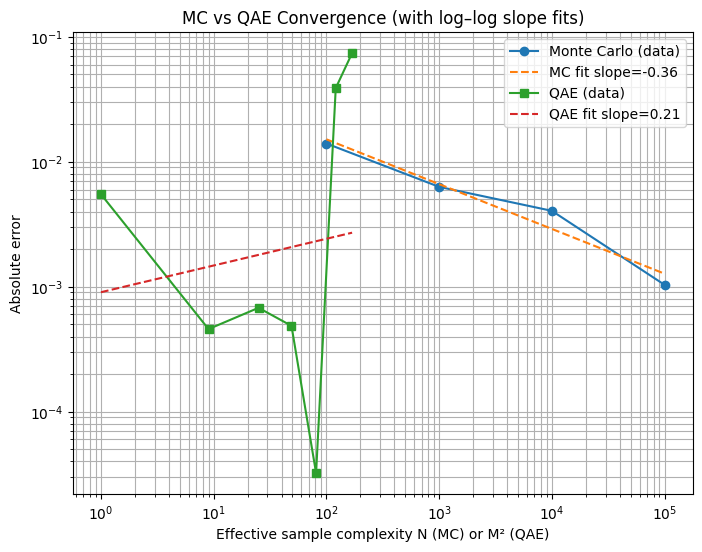

In [11]:
# ---------------------------------------------------------
# Log–log slope estimation (add this below your plot code)
# ---------------------------------------------------------

def loglog_slope(x, y):
    """
    Fit log10(y) = a*log10(x) + b and return (a, b).
    Ignores any non-positive or non-finite points.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    a, b = np.polyfit(np.log10(x), np.log10(y), 1)
    return a, b

# MC slope
slope_mc, intercept_mc = loglog_slope(mc_samples, mc_errors)

# QAE slope (using your stable ks)
slope_qae, intercept_qae = loglog_slope(equivalent_mc, qae_errors)

print("\n=== Log–log slope estimates (error vs effective cost) ===")
print(f"MC fit range:  N in [{min(mc_samples):.0e}, {max(mc_samples):.0e}]")
print(f"QAE fit range: M^2 in [{min(equivalent_mc):.0e}, {max(equivalent_mc):.0e}]")
print(f"MC slope  (theory ~ -0.5): {slope_mc:.4f}")
print(f"QAE slope (theory ~ -1.0): {slope_qae:.4f}")

# Optional: overlay fitted lines on the same plot for visual confirmation
mc_fit = (10**intercept_mc) * (np.array(mc_samples, dtype=float) ** slope_mc)
qae_fit = (10**intercept_qae) * (np.array(equivalent_mc, dtype=float) ** slope_qae)

plt.figure(figsize=(8,6))
plt.loglog(mc_samples, mc_errors, marker='o', label="Monte Carlo (data)")
plt.loglog(mc_samples, mc_fit, linestyle='--', label=f"MC fit slope={slope_mc:.2f}")

plt.loglog(equivalent_mc, qae_errors, marker='s', label="QAE (data)")
plt.loglog(equivalent_mc, qae_fit, linestyle='--', label=f"QAE fit slope={slope_qae:.2f}")

plt.xlabel("Effective sample complexity N (MC) or M² (QAE)")
plt.ylabel("Absolute error")
plt.title("MC vs QAE Convergence (with log–log slope fits)")
plt.grid(True, which="both")
plt.legend()
plt.show()


In [12]:
# ---------------------------------------------------------
# Log–log slope estimation (stable region only for QAE)
# ---------------------------------------------------------

def loglog_slope(x, y):
    """
    Fit log10(y) = a*log10(x) + b and return (a, b).
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    a, b = np.polyfit(np.log10(x), np.log10(y), 1)
    return a, b


# ---------- Monte Carlo slope (all points) ----------
slope_mc, intercept_mc = loglog_slope(mc_samples, mc_errors)


# ---------- QAE slope (FIRST 5 POINTS ONLY) ----------
stable_points = 5   # use only k = 0..4
qae_x_stable = np.array(equivalent_mc[:stable_points], dtype=float)
qae_y_stable = np.array(qae_errors[:stable_points], dtype=float)

slope_qae, intercept_qae = loglog_slope(qae_x_stable, qae_y_stable)


print("\n=== Log–log slope estimates (stable regime) ===")
print(f"MC slope  (theory ≈ -0.5): {slope_mc:.4f}")
print(f"QAE slope (theory ≈ -1.0, k≤4): {slope_qae:.4f}")



=== Log–log slope estimates (stable regime) ===
MC slope  (theory ≈ -0.5): -0.3584
QAE slope (theory ≈ -1.0, k≤4): -0.9045
